# Animal Image Dataset - Exploratory Data Analysis

This notebook explores the animal image dataset that will be used to train the image classification model for the second task.

The goal of this analysis is to:

- understand the dataset structure
- analyze class distribution
- inspect sample images
- analyze image sizes
- understand dataset characteristics before training

The dataset is based on the Animals10 dataset from Kaggle.

After downloading the dataset, the class folder names were translated from Italian to English using a preprocessing script.

Dataset source:
https://www.kaggle.com/datasets/alessiocorrado99/animals10

In [2]:
# Import libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

## Dataset Structure

The dataset contains images of animals organized into folders, where each folder represents a single class.     
Each folder contains images belonging to that class.


In [3]:
# Set dataset path
DATASET_PATH = Path("../data/animals10/raw-img")

classes = sorted(os.listdir(DATASET_PATH))

print("Dataset path:", DATASET_PATH)
print("Number of classes:", len(classes))
print("Classes:", classes)

Dataset path: ..\data\animals10\raw-img
Number of classes: 10
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


## Class Distribution

The following chart shows the number of images available for each class.


In [4]:
# Count images per class
class_counts = {}

for cls in classes:
    class_path = DATASET_PATH / cls
    images = os.listdir(class_path)
    class_counts[cls] = len(images)

df_counts = pd.DataFrame.from_dict(class_counts, orient="index", columns=["image_count"])
df_counts = df_counts.sort_values("image_count", ascending=False)

df_counts

,image_count
dog,4863
spider,4821
chicken,3098
horse,2623
butterfly,2112
cow,1866
squirrel,1862
sheep,1820
cat,1668
elephant,1446


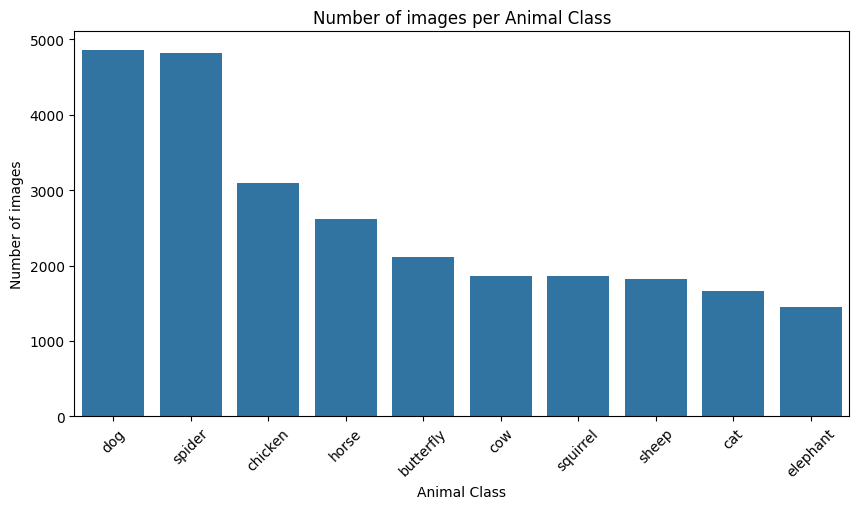

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=df_counts.index,
    y=df_counts["image_count"]
)

plt.title("Number of images per Animal Class")
plt.xlabel("Animal Class")
plt.ylabel("Number of images")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Check for corrupted images
corrupted = []

for cls in classes:
    for img_name in os.listdir(DATASET_PATH / cls):
        try:
            img = Image.open(DATASET_PATH / cls / img_name)
            img.verify()  # verify without loading fully
        except Exception as e:
            corrupted.append((cls, img_name, str(e)))

if corrupted:
    print("Found corrupted images:")
    for c in corrupted:
        print(c)
else:
    print("No corrupted images found.")

No corrupted images found.


The dataset contains images belonging to 10 animal classes.      
The distribution of images across classes is relatively balanced, although some variation between classes is present.  

The largest classes are **dog** and **spider**, containing 4863 and 4821 images respectively,   while the smallest class is **elephant** with 1446 images.    
Other classes such as **chicken**, **horse**, and **butterfly** have a moderate number of samples, while **cow**, **squirrel**, **sheep**, and **cat** contain slightly fewer images.

Although the dataset is not perfectly balanced, the differences are not extreme and every class still contains more than one thousand images.   
Overall, the dataset appears suitable for training a multi-class image classification model.

## Sample Images

To better understand the dataset, we visualize several sample images from different classes.

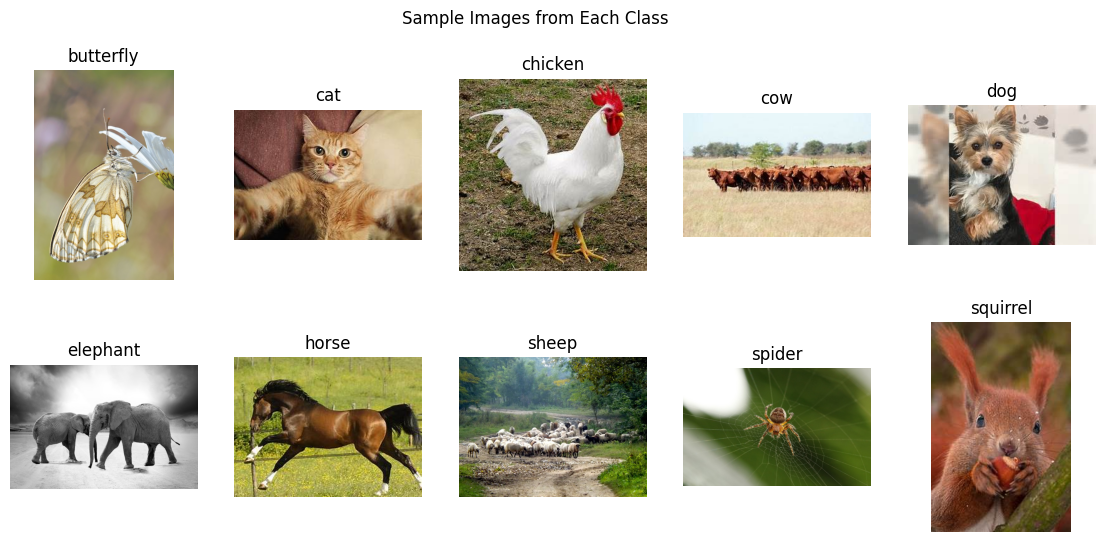

In [6]:
fig, axes = plt.subplots(2,5, figsize=(14,6))

for i, cls in enumerate(classes):
    
    class_path = DATASET_PATH / cls
    
    img_name = os.listdir(class_path)[0]
    img_path = class_path / img_name
    img = Image.open(img_path)
    
    axes[i//5, i%5].imshow(img)
    axes[i//5, i%5].set_title(cls)
    axes[i//5, i%5].axis("off")

plt.suptitle("Sample Images from Each Class")

plt.show()

## Image Resolution Analysis

Images in real-world datasets often have different resolutions.

Before training a neural network, images are usually resized to a fixed resolution (e.g., 224×224 for many CNN architectures).

In this section, we analyze the distribution of image sizes in the dataset.

In [ ]:
# Analyze image sizes
widths = []
heights = []

for cls in classes:
    
    class_path = DATASET_PATH / cls
    
    images = os.listdir(class_path)[:200]   # sample subset
    
    for img_name in images:
        
        img_path = class_path / img_name

        img = Image.open(img_path)
        
        w, h = img.size
        
        widths.append(w)
        heights.append(h)

sizes_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

sizes_df.head()

,width,height
0,426,640
1,640,457
2,426,640
3,425,640
4,426,640


In [ ]:
# Summary statistics of image sizes
sizes_df.describe()

,width,height
count,2000.000000,2000.000000
mean,423.129000,316.697500
std,171.371014,119.177593
min,112.000000,96.000000
25%,300.000000,217.000000
50%,300.000000,300.000000
75%,640.000000,426.000000
max,640.000000,640.000000


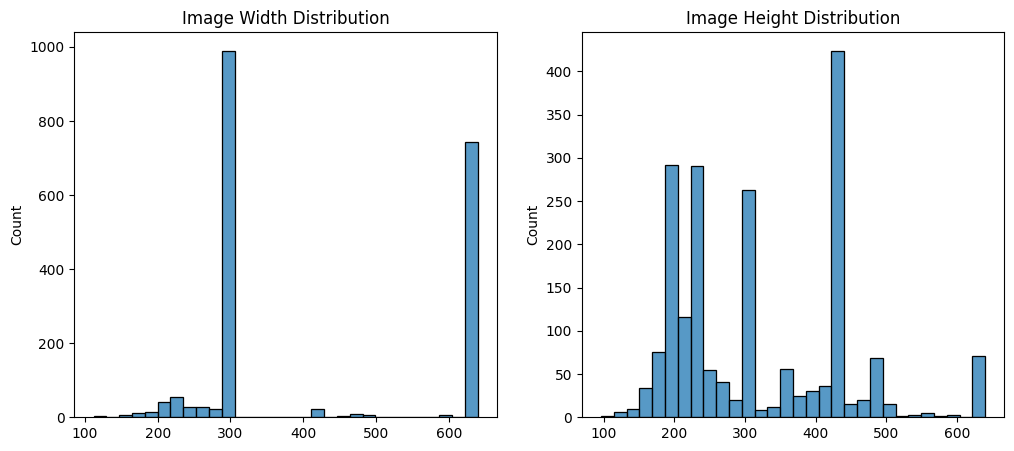

In [ ]:
# Visualize image size distributions
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(widths, bins=30)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30)
plt.title("Image Height Distribution")

plt.show()

Inspection of the image size statistics shows that the dataset contains images with varying resolutions. The average image width is approximately **423 pixels**,   
while the average height is around **317 pixels**, indicating that images are generally wider than they are tall.   
The standard deviation values also suggest a considerable variation in image sizes across the dataset.

The smallest images have dimensions as low as **112х96 pixels**, while the largest images reach **640х640 pixels**.     
The median size is approximately **300х300 pixels**, which indicates that many images fall around this resolution.  
The upper quartile values show that a significant portion of the dataset contains images with widths close to **640 pixels**,   
which is consistent with common camera or dataset resolutions.


### Observations from Image Size Analysis

From the size distribution we observe:

- images have varying resolutions
- many images are relatively large
- convolutional neural networks require fixed input size

Therefore, during training images will be resized to a standard resolution.

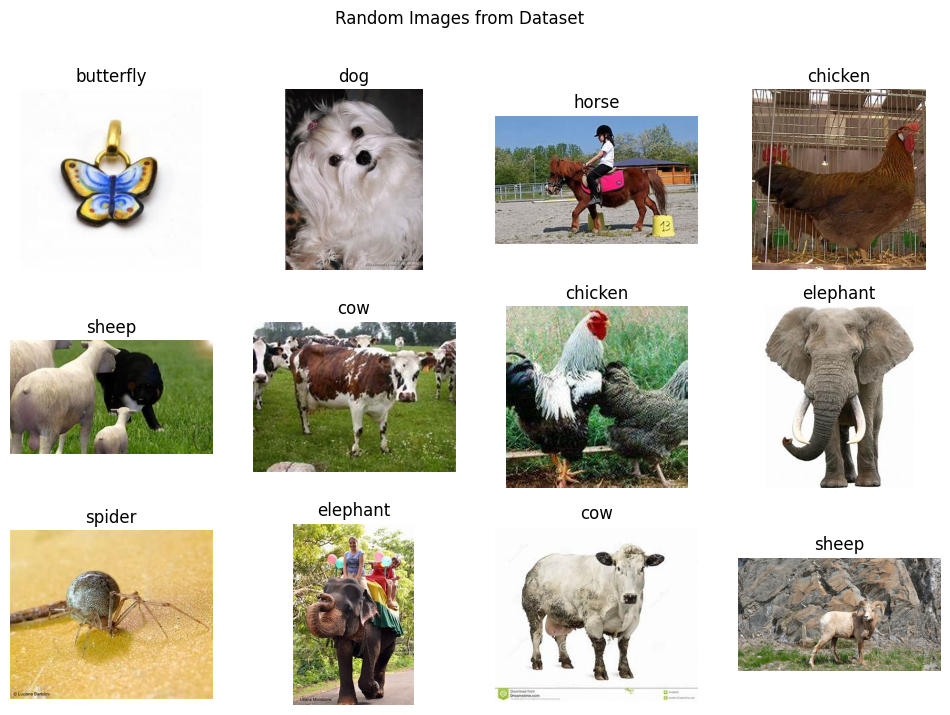

In [13]:
# Display random images from dataset
import random

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax in axes.flatten():
    
    cls = random.choice(classes)
    
    img_name = random.choice(os.listdir(DATASET_PATH / cls))
    
    img_path = DATASET_PATH / cls / img_name
    
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.suptitle("Random Images from Dataset")

plt.show()

## Dataset Summary

The dataset contains images of 10 animal classes:

- dog
- cat
- cow
- horse
- elephant
- butterfly
- chicken
- sheep
- spider
- squirrel

Key observations:

- the dataset contains thousands of images across 10 classes
- class distribution is reasonably balanced
- images vary in resolution and aspect ratio
- preprocessing such as resizing and normalization will be required before training

This dataset is suitable for training an image classification model.

## Preprocessing Recommendations

Based on the exploratory analysis of the dataset, here are the key preprocessing steps recommended before training the image classification model:

- **Resize images to a fixed size**  

- **Handle varying aspect ratios**  
  Images are generally wider than tall with sizes ranging from 112×96 to 640×640.  

- **Normalize pixel values**  
  Scale pixels to [0, 1] or use ImageNet statistics 

- **Apply data augmentation**   
  Random flip, rotation, brightness/contrast/saturation adjustments

- **Handle minor class imbalance**  
  Dog (4863) and spider (4821) have more samples than elephant (1446).  

These steps will prepare the dataset for efficient and effective model training while preserving important visual features.